# tree계열 이외의 분류 알고리즘

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
%matplotlib inline    # 그래프 안 나올 때

UsageError: unrecognized arguments: # 그래프 안 나올 때


In [4]:
mem = pd.read_csv("./data/member.csv")
tran = pd.read_csv("./data/transaction.csv")

In [5]:
mem.head() # recency: 기준 날짜(현재날짜)-고객의 최근 구매일

,id,recency,zip_code,is_referral,channel,conversion
0,906145,10,Surburban,0,Phone,0
1,184478,6,Rural,1,Web,0
2,394235,7,Surburban,1,Web,0
3,130152,9,Rural,1,Web,0
4,940352,2,Urban,0,Web,0


In [6]:
tran.head()

,id,num_item,total_amount
0,906145,5,34000
1,906145,1,27000
2,906145,4,33000
3,184478,4,29000
4,394235,4,33000


In [7]:
mem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           64000 non-null  int64 
 1   recency      64000 non-null  int64 
 2   zip_code     64000 non-null  object
 3   is_referral  64000 non-null  int64 
 4   channel      64000 non-null  object
 5   conversion   64000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 2.9+ MB


In [8]:
tran.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196836 entries, 0 to 196835
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            196836 non-null  int64
 1   num_item      196836 non-null  int64
 2   total_amount  196836 non-null  int64
dtypes: int64(3)
memory usage: 4.5 MB


In [9]:
mem['id'].nunique()

64000

In [8]:
tran['id'].nunique() # 64000명의 회원에 대한 데이터구나

64000

* 쇼핑몰 고객 데이터, 프로모션 쿠폰을 발행하고 사용 여부 데이터 수집
* mem : 고객id, 최근 방문일, 사는 지역, 추천여부, 주요접속채널, 쿠폰사용여부(target)
* tran : 고객id, 구매수량, 총 구매금액
* 전통적 마케팅 분석 방법 RFM 기법을 활용해 고객 데이터에서 파생변수 생성 후 분석
* R: Recency: 현재일 - 최근 구매일
* F: Frequency: 구매빈도
* M: Monetary: 구매 금액
* 종속변수: conversion => 고객이 프로모션에 반응 했는가? 1 =yes, 0 = no

In [10]:
from ydata_profiling import ProfileReport

C:\Users\Admin\miniforge3\envs\fintech\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
!pip install pandas==1.5.3
!pip install ydata-profiling==4.6.4   # 버전 다운그레이드했음 

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [12]:
# 버전 다운그레이드 잘 됐는지 확인
import pandas as pd
import ydata_profiling
import sys

print("pandas:", pd.__version__)
print("ydata_profiling:", ydata_profiling.__version__)
print("python path:", sys.executable)

pandas: 1.5.3
ydata_profiling: v4.6.4
python path: C:\Users\Admin\miniforge3\envs\fintech\python.exe


In [12]:
for name, df in zip(['mem', 'tran'], [mem, tran]):
    profile = ProfileReport(df, title=f"{name} EDA", explorative=True)
    profile.to_file(f"./data/{name}_eda_report.html")
# explorative=True를 하면 더 많은 상관관계분석, 더 많은 통계지표, 이상치 분석 강화 등이 추가됨

Export report to file: 100%|████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 287.08it/s]


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
mem_train, mem_test = train_test_split(mem, test_size=0.4, random_state=42, stratify=mem['conversion'])
mem_train.head()
mem_train['id'].nunique()

38400

In [16]:
tran_train, tran_test = train_test_split(tran, test_size=0.4, random_state=42)
tran_train.head()
tran_train['id'].nunique()

56333

In [17]:
# 모델 학습용 회원들의 거래 데이터만 추출하기 위해 필요한 전처리 단계
tran_train=tran[tran['id'].isin(mem_train['id'])]
print(len(tran_train), mem_train['id'].nunique(), tran_train['id'].nunique())
tran_test=tran[~tran['id'].isin(mem_train['id'])]
print(len(tran_test), mem_test['id'].nunique(), tran_test['id'].nunique())

118167 38400 38400
78669 25600 25600


In [18]:
mem_test.to_csv("./data/member_test.csv", index=False)
tran_test.to_csv("./data/transaction_test.csv", index=False)

# 문자 컬럼과 숫자 컬럼 분리 후 EDA 

In [19]:
mem_train.columns
# 고객id, 최근 방문일, 사는 지역, 추천여부, 주요접속채널, 쿠폰사용여부(target)

Index(['id', 'recency', 'zip_code', 'is_referral', 'channel', 'conversion'], dtype='object')

In [20]:
# mem 데이터에서 숫자형은 recency밖에 없음. 나머지는 0과1 존재하는 범주형이라고 볼 수 있음
num_cols = mem_train[['recency']].columns
cat_cols = mem_train[['zip_code', 'is_referral', 'channel', 'conversion']].columns
print(num_cols)
print(cat_cols)

Index(['recency'], dtype='object')
Index(['zip_code', 'is_referral', 'channel', 'conversion'], dtype='object')


============================== recency ==============================


count    38400.000000
mean         5.756224
std          3.506353
min          1.000000
25%          2.000000
50%          5.000000
75%          9.000000
max         12.000000
Name: recency, dtype: float64

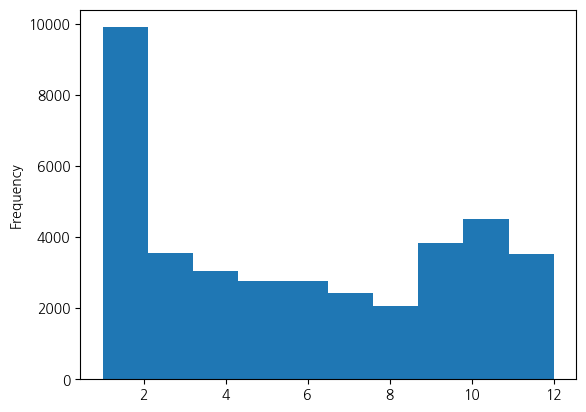

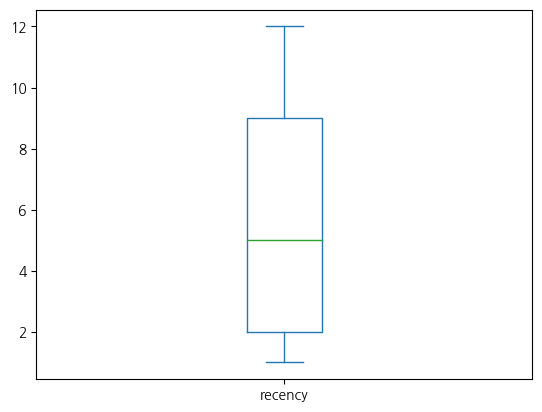

,conversion
recency,
1,0.191776
2,0.177582
3,0.169291
4,0.149852
5,0.142857
6,0.141312
7,0.136175
8,0.127229
12,0.123588


In [21]:
for col in num_cols:
    print("="*30, col, "="*30)
    display(mem_train[col].describe())
    mem_train[col].plot(kind='hist')
    plt.show()
    mem_train[col].plot(kind='box')
    plt.show()
    display(mem_train[[col, 'conversion']].groupby(col).mean().sort_values(by='conversion', ascending=False))

============================== zip_code ==============================


count         38400
unique            3
top       Surburban
freq          17252
Name: zip_code, dtype: object

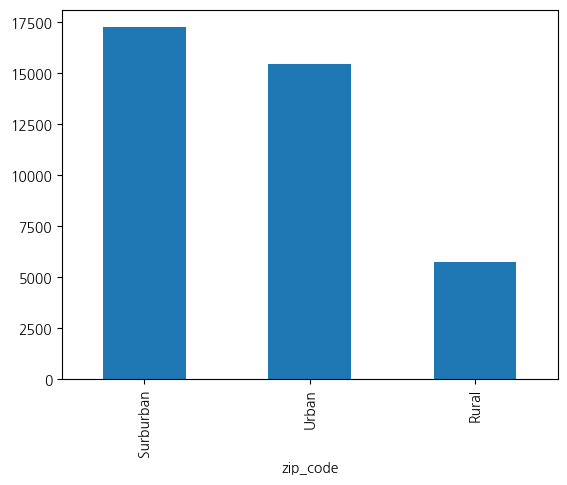

,conversion
zip_code,
Rural,0.189619
Surburban,0.141955
Urban,0.136263


============================== is_referral ==============================


count    38400.000000
mean         0.500130
std          0.500006
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: is_referral, dtype: float64

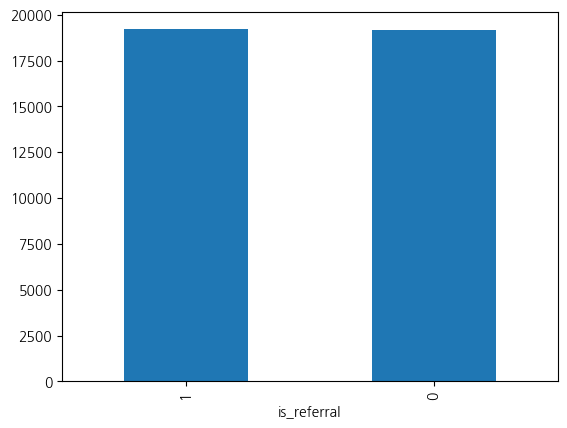

,conversion
is_referral,
0,0.172493
1,0.121062


============================== channel ==============================


count     38400
unique        3
top       Phone
freq      16888
Name: channel, dtype: object

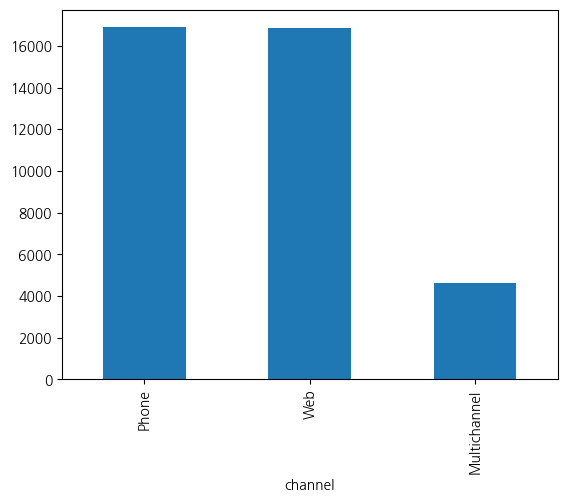

,conversion
channel,
Multichannel,0.174764
Web,0.158719
Phone,0.127132


In [33]:
for col in cat_cols[:-1]:
    print("="*30, col, "="*30)
    display(mem_train[col].describe(include='all'))
    mem_train[col].value_counts().plot(kind='bar')
    plt.show()
    display(mem_train[[col, 'conversion']].groupby(col).mean().sort_values(by='conversion', ascending=False))

In [23]:
import sys
!{sys.executable} -m pip install matplotlib==3.7.2

In [22]:
import matplotlib
import pandas as pd

print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)

pandas: 1.5.3
matplotlib: 3.7.2


In [62]:
tran_train.columns

Index(['id', 'num_item', 'total_amount'], dtype='object')

============================== id ==============================


count    118167.000000
mean     549809.088104
std      258979.321858
min      100032.000000
25%      326777.500000
50%      549708.000000
75%      772709.000000
max      999995.000000
Name: id, dtype: float64

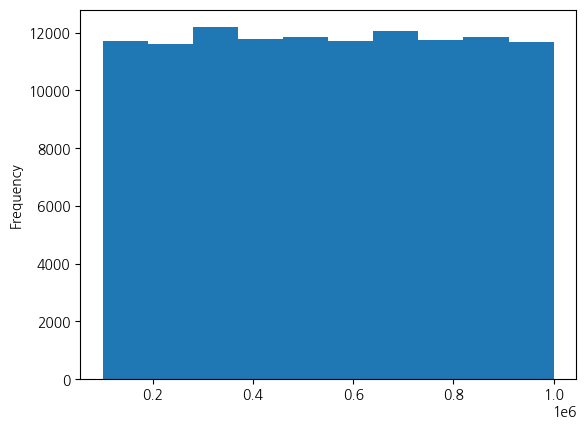

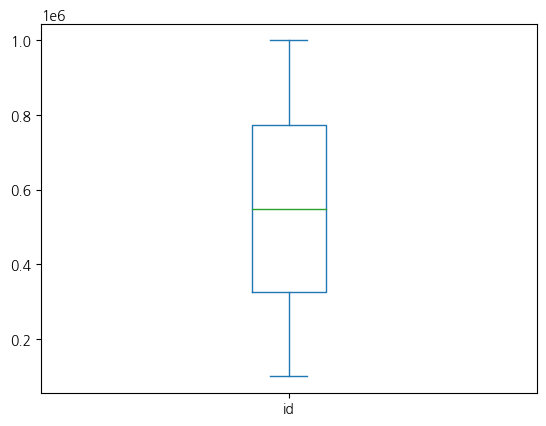

============================== num_item ==============================


count    118167.000000
mean          3.081503
std           1.479529
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           6.000000
Name: num_item, dtype: float64

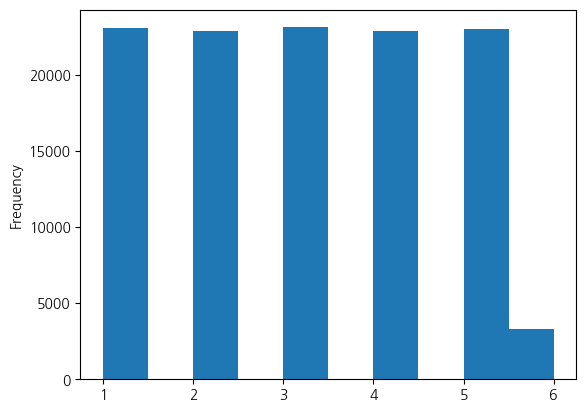

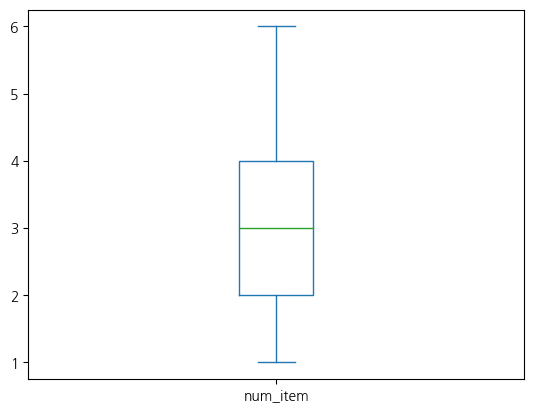

============================== total_amount ==============================


count    118167.000000
mean      21862.034240
std        8216.635961
min        8000.000000
25%       15000.000000
50%       22000.000000
75%       29000.000000
max       38000.000000
Name: total_amount, dtype: float64

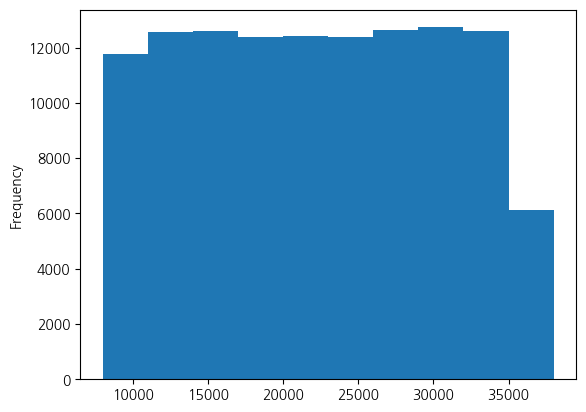

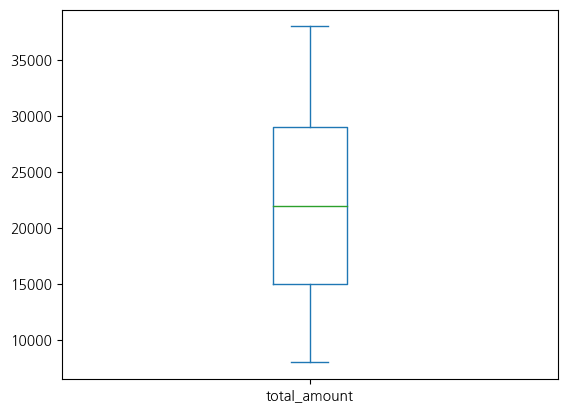

In [24]:
for col in tran_train.columns:
    print("=" * 30, col, "=" * 30)
    display(tran_train[col].describe())
    tran_train[col].plot(kind='hist')
    plt.show()
    tran_train[col].plot(kind='box')
    plt.show()

# tran_train에서 구매빈도, 금액 집계하기

In [25]:
tran_train.head()

,id,num_item,total_amount
0,906145,5,34000
1,906145,1,27000
2,906145,4,33000
3,184478,4,29000
6,130152,2,11000


In [26]:
# 고객 id별 평균 구매 개수와 금액
mean_item_amount = tran_train.groupby('id').mean()
mean_item_amount.columns = ['mean_num_item', 'mean_total_amount']
mean_item_amount

,mean_num_item,mean_total_amount
id,,
100032,2.666667,20666.666667
100036,3.000000,25800.000000
100101,2.666667,22666.666667
100105,4.000000,29000.000000
100113,3.800000,20000.000000
...,...,...
999755,1.000000,10000.000000
999771,4.333333,20000.000000
999911,2.500000,18500.000000


In [27]:
# 고객 id별 평균 구매 빈도
freq = tran_train.groupby('id')[['id']].count()
freq.columns = ['frequency']
freq

,frequency
id,
100032,3
100036,5
100101,3
100105,2
100113,5
...,...
999755,1
999771,3
999911,2


In [28]:
# 고객 id별 총 구매 개수와 총 금액
total_item_amount = tran_train.groupby('id').sum()
total_item_amount.columns = ['total_num_item', 'total_total_amount']
total_item_amount

,total_num_item,total_total_amount
id,,
100032,8,62000
100036,15,129000
100101,8,68000
100105,8,58000
100113,19,100000
...,...,...
999755,1,10000
999771,13,60000
999911,5,37000


In [29]:
# id를 기준으로 3개 집계내역 데이터프레임을 1개로 합치기
temp = freq.join(total_item_amount)
# 왼쪽 데이터프레임(freq)을 기준으로 오른쪽 데이터프레임(total_item_amount)을 옆으로 붙인다.
# left join과 동일
groupby_result = temp.join(mean_item_amount)

In [30]:
groupby_result = groupby_result.reset_index()
groupby_result

,id,frequency,total_num_item,total_total_amount,mean_num_item,mean_total_amount
0,100032,3,8,62000,2.666667,20666.666667
1,100036,5,15,129000,3.000000,25800.000000
2,100101,3,8,68000,2.666667,22666.666667
3,100105,2,8,58000,4.000000,29000.000000
4,100113,5,19,100000,3.800000,20000.000000
...,...,...,...,...,...,...
38395,999755,1,1,10000,1.000000,10000.000000
38396,999771,3,13,60000,4.333333,20000.000000
38397,999911,2,5,37000,2.500000,18500.000000
38398,999981,4,8,91000,2.000000,22750.000000


In [31]:
train_data = pd.merge(mem_train, groupby_result, how='inner', on='id')
# mem_train에도 있고 groupby_result에도 있는 id만 남긴다.
train_data

,id,recency,zip_code,is_referral,channel,conversion,frequency,total_num_item,total_total_amount,mean_num_item,mean_total_amount
0,913028,9,Rural,1,Web,0,2,8,30000,4.000000,15000.000000
1,448921,3,Surburban,0,Web,0,5,17,140000,3.400000,28000.000000
2,909398,11,Urban,1,Web,0,4,14,82000,3.500000,20500.000000
3,327583,2,Urban,0,Multichannel,0,3,13,72000,4.333333,24000.000000
4,248352,7,Surburban,0,Web,0,2,2,34000,1.000000,17000.000000
...,...,...,...,...,...,...,...,...,...,...,...
38395,305703,4,Urban,1,Web,0,1,1,9000,1.000000,9000.000000
38396,538867,2,Urban,1,Web,0,2,5,25000,2.500000,12500.000000
38397,608999,1,Surburban,0,Web,0,3,7,62000,2.333333,20666.666667
38398,986281,11,Surburban,1,Web,0,5,16,104000,3.200000,20800.000000


In [32]:
train_data.columns

Index(['id', 'recency', 'zip_code', 'is_referral', 'channel', 'conversion',
       'frequency', 'total_num_item', 'total_total_amount', 'mean_num_item',
       'mean_total_amount'],
      dtype='object')

============================== frequency ==============================


count    38400.000000
mean         3.077266
std          1.384528
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: frequency, dtype: float64

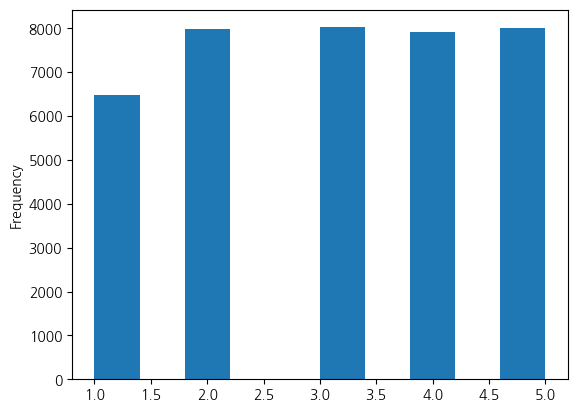

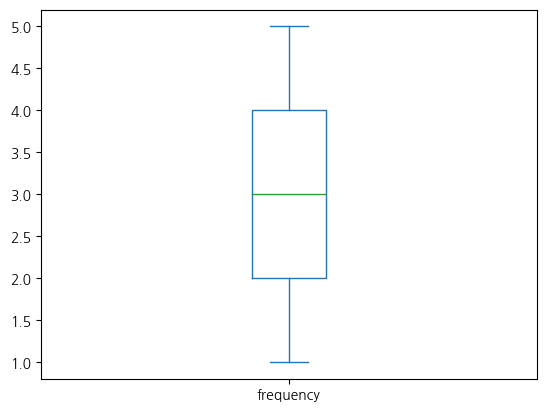

,conversion
frequency,
3,0.182147
5,0.177647
2,0.174169
4,0.172392
1,0.000000


============================== total_num_item ==============================


count    38400.000000
mean         9.482604
std          5.054144
min          1.000000
25%          5.000000
50%          9.000000
75%         13.000000
max         28.000000
Name: total_num_item, dtype: float64

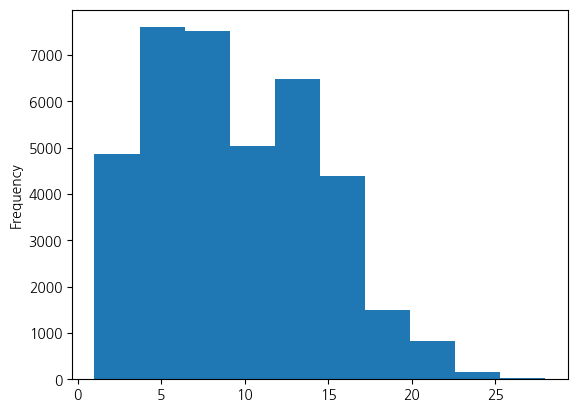

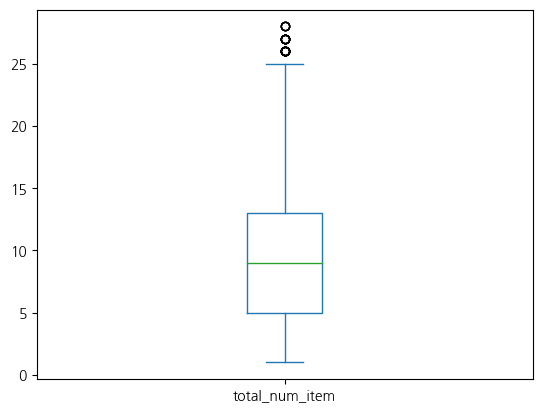

,conversion
total_num_item,
28,1.000000
27,1.000000
26,1.000000
25,1.000000
24,0.772727
23,0.561905
22,0.560694
21,0.440154
20,0.390000


============================== total_total_amount ==============================


count     38400.000000
mean      67275.286458
std       33689.678324
min        8000.000000
25%       39000.000000
50%       66000.000000
75%       93000.000000
max      184000.000000
Name: total_total_amount, dtype: float64

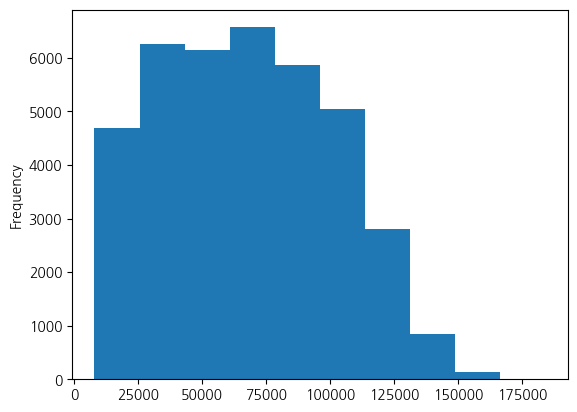

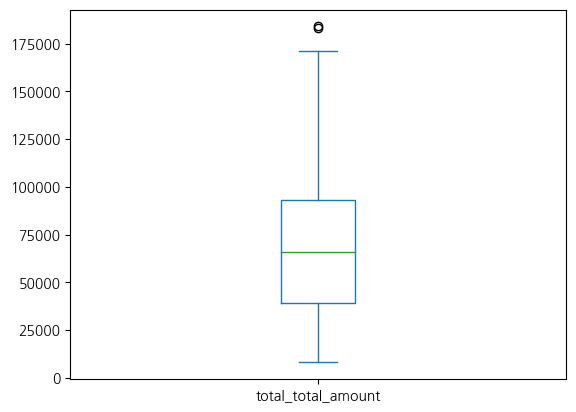

,conversion
total_total_amount,
184000,1.0
162000,1.0
183000,1.0
171000,1.0
157000,1.0
...,...
14000,0.0
15000,0.0
9000,0.0


============================== mean_num_item ==============================


count    38400.000000
mean         3.071370
std          0.974829
min          1.000000
25%          2.500000
50%          3.000000
75%          3.750000
max          6.000000
Name: mean_num_item, dtype: float64

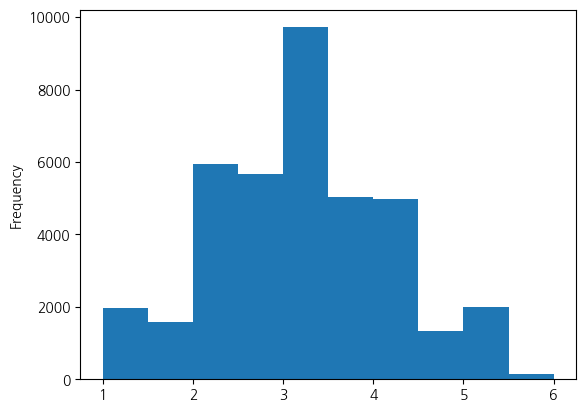

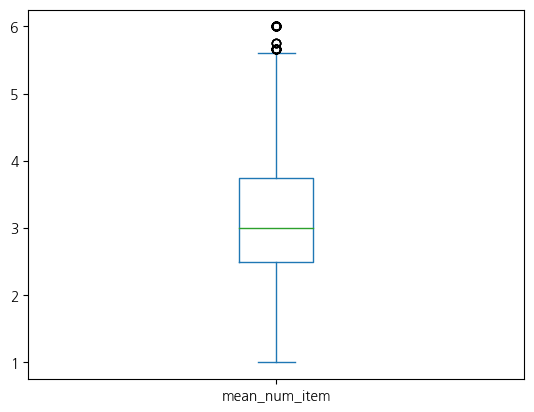

,conversion
mean_num_item,
6.000000,1.000000
5.750000,1.000000
5.666667,1.000000
5.600000,1.000000
5.500000,1.000000
5.400000,1.000000
5.333333,1.000000
5.250000,1.000000
5.200000,1.000000


============================== mean_total_amount ==============================


count    38400.000000
mean     21811.800781
std       5390.194410
min       8000.000000
25%      18333.333333
50%      22000.000000
75%      25333.333333
max      38000.000000
Name: mean_total_amount, dtype: float64

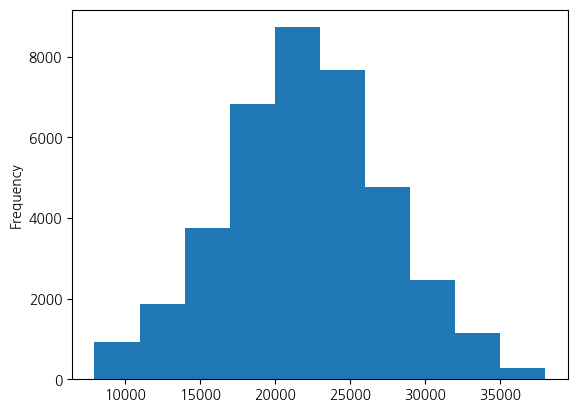

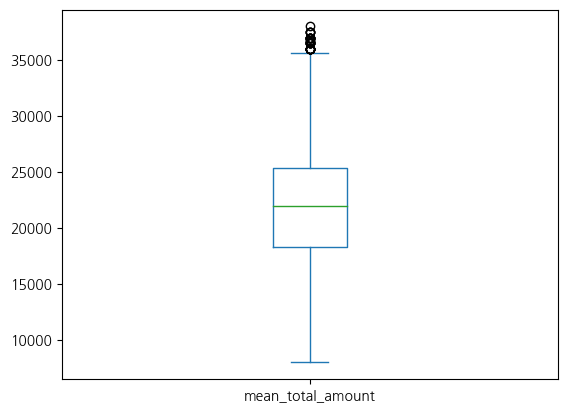

,conversion
mean_total_amount,
38000.000000,1.0
33250.000000,1.0
34200.000000,1.0
34250.000000,1.0
34333.333333,1.0
...,...
10600.000000,0.0
11750.000000,0.0
11600.000000,0.0


In [33]:
new_cols=['frequency', 'total_num_item', 'total_total_amount', 'mean_num_item','mean_total_amount']
for col in new_cols:
    print("="*30, col, "="*30)
    display(train_data[col].describe())
    train_data[col].plot(kind='hist')
    plt.show()
    train_data[col].plot(kind='box')
    plt.show()
    display(train_data[[col, 'conversion']].groupby(col).mean().sort_values(by='conversion', ascending=False))

In [34]:
train_data

,id,recency,zip_code,is_referral,channel,conversion,frequency,total_num_item,total_total_amount,mean_num_item,mean_total_amount
0,913028,9,Rural,1,Web,0,2,8,30000,4.000000,15000.000000
1,448921,3,Surburban,0,Web,0,5,17,140000,3.400000,28000.000000
2,909398,11,Urban,1,Web,0,4,14,82000,3.500000,20500.000000
3,327583,2,Urban,0,Multichannel,0,3,13,72000,4.333333,24000.000000
4,248352,7,Surburban,0,Web,0,2,2,34000,1.000000,17000.000000
...,...,...,...,...,...,...,...,...,...,...,...
38395,305703,4,Urban,1,Web,0,1,1,9000,1.000000,9000.000000
38396,538867,2,Urban,1,Web,0,2,5,25000,2.500000,12500.000000
38397,608999,1,Surburban,0,Web,0,3,7,62000,2.333333,20666.666667
38398,986281,11,Surburban,1,Web,0,5,16,104000,3.200000,20800.000000


# 거리기반의 알고리즘을 사용시 독립변수들 간의 단위를 꼭 맞춰 주어야 함
# 스케일링
* MinMaxScaler: 모든 숫자를 0-1사이의 숫자로 변환 - 데이터 분포의 모양을 그대로 유지
* StandardScaler: 평균을 0, 표준편차를 1로 하는 정규분포 형태로 변환 - 데이터의 분포 모양이 정규 분포로 바뀜
* RobustScaler: 사분위수를 이용해서 데이터를 스케일링 - 데이터에 이상값이 있을 때 사용, 이상값에 영향을 최소화

# 머신러닝 모델별 스케일러

**분류 분석**
* knn(최근접이웃): MinMaxScaler, 이상치가 있는 경우 RobustScaler
* SVM(서포트 벡터 머신): StandardScaler, 이상치가 있는 경우 RobustScaler
* Logistic Regression: StandardScaler, 이상치가 있는 경우 RobustScaler
* Naive Bayes: 스케일링 불필요, 이상치가 있는 경우에도 안해도 됨

**회귀 분석**
* Linear / Ridge / Lasso: StandardScaler, 이상치가 있는 경우 RobustScaler

**군집 분석**
* KMeans / DBSCAN: MinMax or StandardScaler, 이상치가 있는 경우 RobustScaler

**Tree 계열**
* DecisionTree, RandomForest, XGBoost: 스케일링 불필요, 이상치가 있는 경우에도 안해도 됨

**분류/회귀 분석**
* 인공신경망: MinMax or StandardScaler, 이상치가 있는 경우 RobustScaler

* 수치형: 결측 없음, boxplot상 이상치가 약간 있으나 실제 이상치는 아님 => standard scaler 사용
* 범주형: 결측 없음 => one-hot encoding 사용

In [36]:
X = train_data.drop(['id', 'conversion'], axis=1)
y = train_data['conversion']

In [37]:
X

,recency,zip_code,is_referral,channel,frequency,total_num_item,total_total_amount,mean_num_item,mean_total_amount
0,9,Rural,1,Web,2,8,30000,4.000000,15000.000000
1,3,Surburban,0,Web,5,17,140000,3.400000,28000.000000
2,11,Urban,1,Web,4,14,82000,3.500000,20500.000000
3,2,Urban,0,Multichannel,3,13,72000,4.333333,24000.000000
4,7,Surburban,0,Web,2,2,34000,1.000000,17000.000000
...,...,...,...,...,...,...,...,...,...
38395,4,Urban,1,Web,1,1,9000,1.000000,9000.000000
38396,2,Urban,1,Web,2,5,25000,2.500000,12500.000000
38397,1,Surburban,0,Web,3,7,62000,2.333333,20666.666667
38398,11,Surburban,1,Web,5,16,104000,3.200000,20800.000000


In [38]:
y.value_counts(normalize=True)
# normalize=True: 개수가 아니라 비율로 보여줘라

0    0.853229
1    0.146771
Name: conversion, dtype: float64

In [39]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [64]:
X_valid.columns

Index(['recency', 'zip_code', 'is_referral', 'channel', 'frequency',
       'total_num_item', 'total_total_amount', 'mean_num_item',
       'mean_total_amount'],
      dtype='object')

# 파이프라인으로 컬럼 전처리

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [41]:
X_train.columns

Index(['recency', 'zip_code', 'is_referral', 'channel', 'frequency',
       'total_num_item', 'total_total_amount', 'mean_num_item',
       'mean_total_amount'],
      dtype='object')

In [42]:
num_cols = ['recency', 'frequency', 'total_num_item', 'total_total_amount', 'mean_num_item', 'mean_total_amount']
cat_cols = ['zip_code', 'is_referral', 'channel']
print(num_cols)
print(cat_cols)

['recency', 'frequency', 'total_num_item', 'total_total_amount', 'mean_num_item', 'mean_total_amount']
['zip_code', 'is_referral', 'channel']


In [43]:
num_pipe = Pipeline(steps=[
    ("std", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("ohe", OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ('nums', num_pipe, num_cols),
    ('cats', cat_pipe, cat_cols)
], remainder='drop')
# remainder='drop': 지정한 컬럼말고 나머지 컬럼은 전부 버려라

# 모델 및 하이퍼파라미터 정의 1개만

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, classification_report

In [46]:
dtc  = DecisionTreeClassifier(random_state=42, class_weight='balanced')

pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', dtc)
])

pipe.fit(X_train,  y_train)
proba = pipe.predict_proba(X_valid)[:, 1]
pred = pipe.predict(X_valid)

print(roc_auc_score(y_valid, proba))
print(classification_report(y_valid, pred))

0.5861252681195754
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      6553
           1       0.29      0.29      0.29      1127

    accuracy                           0.79      7680
   macro avg       0.58      0.58      0.58      7680
weighted avg       0.79      0.79      0.79      7680



# 교차검증과 하이퍼파라미터 튜닝 추가

In [47]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

In [ ]:
DecisionTreeClassifier()

In [49]:
scv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param = dict(
    model__criterion=["gini", "entropy", "log_loss"],
    model__max_depth=[1,3,5,7,9],
    model__min_samples_split=[2,4,6,8,10],  
)

randcv = RandomizedSearchCV(estimator=pipe, cv=scv, n_iter=100, scoring='roc_auc', n_jobs=-1, param_distributions=param)

randcv.fit(X_train, y_train)
proba = randcv.predict_proba(X_valid)[:,1]
pred = randcv.predict(X_valid)

print('roc_auc: ', roc_auc_score(y_valid, proba))
print("classification_report\n", classification_report(y_valid, pred))
print("best_params: ", randcv.best_params_)

C:\Users\Admin\miniforge3\envs\fintech\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 75 is smaller than n_iter=100. Running 75 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


roc_auc:  0.752227046114062
classification_report
               precision    recall  f1-score   support

           0       0.92      0.71      0.80      6553
           1       0.27      0.65      0.39      1127

    accuracy                           0.70      7680
   macro avg       0.60      0.68      0.59      7680
weighted avg       0.83      0.70      0.74      7680

best_params:  {'model__min_samples_split': 2, 'model__max_depth': 7, 'model__criterion': 'entropy'}


# 서포트 벡터 SVC를 사용해서 분석
* StandardScaler
* 카테고리 변수를 제외하고 StandardScaler를 사용하는 것이 좋음
**“두 그룹 사이를 가장 넓게(여유 있게) 나누는 선/면”**을 찾는 모델입니다.  
로지스틱 회귀처럼 선형 경계지만, ‘기준(목표)’가 다릅니다.
### 1) SVM이 말하는 ‘경계면’이 뭔가요?
경계면은 “0과 1을 나누는 기준선/기준면”입니다.
- 2차원: 직선  
- 3차원: 평면  
- 고차원: 초평면

SVM은 그 중에서 **가장 안전하게 나누는 경계**를 고릅니다.
### 2) “마진 최대화”가 핵심
SVM은 이렇게 생각합니다:
> “경계면에 가장 가까운 데이터들과의 거리를 최대화하자”
여기서 경계에 가장 가까운 데이터들이 **Support Vector(서포트 벡터)** 입니다.  
즉, 모든 데이터가 아니라 **가장 가까운 몇 점이 경계를 결정**합니다.

In [50]:
from sklearn.svm import SVC

In [51]:
svc  = SVC(random_state=42, class_weight='balanced', probability=True)
# probability=True: 예측 결과를 '확률'로도 출력할 수 있게 하겠다
pipe2 = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', svc)
])

pipe2.fit(X_train,  y_train)
proba2 = pipe2.predict_proba(X_valid)[:, 1]
pred2 = pipe2.predict(X_valid)

print(roc_auc_score(y_valid, proba))
print(classification_report(y_valid, pred))

0.752227046114062
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      6553
           1       0.27      0.65      0.39      1127

    accuracy                           0.70      7680
   macro avg       0.60      0.68      0.59      7680
weighted avg       0.83      0.70      0.74      7680



# KNN(K-Nearest Neighbor)
### ✅ 한 줄 요약  
**“가까운 이웃을 보고 따라 하는” 분류기**입니다.  
새 데이터가 들어오면 주변의 비슷한 사례(k개)를 찾아 다수결로 결정해요.
---
### 1) 어떻게 예측하나요? (직관)
예를 들어 k=5면:
1) 새 고객과 “가장 비슷한” 고객 5명을 찾고  
2) 그 5명 중 승인(1)이 더 많으면 → 승인(1)
즉, **기억 기반(메모리 기반)** 모델이라고도 합니다.
---
### 2) 왜 스케일링이 필수인가요?
kNN은 “거리”를 계산합니다.  
그런데 컬럼마다 단위가 다르면 문제가 생겨요.
예)
- income: 50,000,000 (수천만 단위)
- credit_score: 650 (수백 단위)
그냥 거리를 계산하면 income이 압도적으로 크게 작용 → **왜곡**  
그래서 `StandardScaler` 같은 스케일링이 거의 필수입니다.
---
### 3) k 값이 작으면/크면?
- k가 **작으면**: 아주 가까운 몇 개만 보고 판단 → **과적합**(노이즈에 민감)
- k가 **크면**: 멀리 있는 이웃까지 섞어서 판단 → **과소적합**(경계가 둔해짐)
---
### 4) weights는 뭐예요?
- `uniform`: 이웃을 “동일하게” 투표
- `distance`: 더 가까운 이웃에게 “가중치 더 줌”  
  (종종 성능이 좋아짐)
---
### 5) 장단점
✅ 구현 쉽고 직관적, 비선형 패턴도 어느 정도 잡음  
❌ 데이터가 많아질수록 예측이 느려짐(매번 이웃 찾기)  
❌ 고차원(컬럼 많음)에서는 거리 개념이 흐려져 성능이 떨어질 수 있음
---
### 6) 언제 쓰나요?
✅ “빠른 비교용 모델”, “개념 설명용”으로 매우 좋음  
✅ 데이터가 아주 크지 않을 때

In [52]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

In [55]:
num_pipe2 = Pipeline(steps=[
    ("mmx", MinMaxScaler())
])

cat_pipe2 = Pipeline(steps=[
    ("ohe", OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocess2 = ColumnTransformer(transformers=[
    ('nums', num_pipe2, num_cols),
    ('cats', cat_pipe2, cat_cols)
], remainder='drop')

In [56]:
knn = KNeighborsClassifier()

pipe3 = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", knn)
])

pipe3.fit(X_train, y_train)
proba3 = pipe3.predict_proba(X_valid)[:, 1]
pred3 = pipe3.predict(X_valid)

print(roc_auc_score(y_valid, proba3))
print(classification_report(y_valid, pred3))

0.664959701328232
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      6553
           1       0.44      0.16      0.24      1127

    accuracy                           0.85      7680
   macro avg       0.65      0.56      0.58      7680
weighted avg       0.81      0.85      0.82      7680



# KNN의 하이퍼파라미터 튜닝
* n_neighbors= ? 
* 전체 샘플수가 적을 때 10000개 이하일 때 3, 5, 7 같은 홀수 값
* 전체 샘플수가 10000개 초과시 루트(n), log2(n)

In [57]:
len(X_train)

30720

# 최적K는?
| 기준 | √n | log₂(n) |
|------|------|------|
| k 크기 | 매우 큼 | 매우 작음 |
| 모델 특성 | 부드러움 (Global 평균화) | 민감함 (Local 패턴 유지) |
| 편향(Bias) | 증가 | 낮음 |
| 분산(Variance) | 감소 | 높음 |
| 대용량 데이터 | 안정적 | 과적합 가능 |
| 불균형 데이터 | 다수 클래스 쏠림 가능 | 소수 클래스 탐지에 유리 |
| 위험 | 언더피팅 | 오버피팅 |

In [58]:
# 최적 k 계산하기 (k값 후보들 다양하게 만들기)
n = len(X_train)
k_sqrt = int(np.sqrt(n))
k_log2 = int(np.log2(n))
print("n:",n, 'sqrt: ', k_sqrt, 'k_log2: ', k_log2)

n: 30720 sqrt:  175 k_log2:  14


In [59]:
sorted(set(
    [3,5,7,9,11,15] +
    [max(1, k_log2-10), k_log2-5, k_log2, k_log2+5, k_log2+10] +
    [max(1, k_sqrt-100), max(1, k_sqrt-50), k_sqrt, k_sqrt+50, k_sqrt+100]
))
# set(): 중복제거
# sorted(): 오름차순 정렬

[3, 4, 5, 7, 9, 11, 14, 15, 19, 24, 75, 125, 175, 225, 275]

In [60]:
k_candidates = sorted(set(
    [3,5,7,9,11,15] +
    [max(1, k_log2-10), k_log2-5, k_log2, k_log2+5, k_log2+10] +
    [max(1, k_sqrt-100), max(1, k_sqrt-50), k_sqrt, k_sqrt+50, k_sqrt+100]
))

k_candidates = [k for k in k_candidates if k > 0 and k % 2 ==1]
k_candidates

[3, 5, 7, 9, 11, 15, 19, 75, 125, 175, 225, 275]

In [ ]:
KNeighborsClassifier()

In [61]:
params = dict(
    model__n_neighbors=k_candidates,
    model__weights=['uniform', 'distance'],
    model__p=[1, 2],
    )

randcv3 = RandomizedSearchCV(
    estimator=pipe3,
    param_distributions=params,
    scoring='roc_auc',
    cv=scv,
    n_jobs=-1,
    verbose=1
    )

randcv3.fit(X_train, y_train)
proba4 = randcv3.predict_proba(X_valid)[:, 1]
pred4 = randcv3.predict(X_valid)

print(roc_auc_score(y_valid, proba4))
print(classification_report(y_valid, pred4))
print(randcv3.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
0.7578313393311598
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      6553
           1       0.91      0.03      0.05      1127

    accuracy                           0.86      7680
   macro avg       0.88      0.51      0.49      7680
weighted avg       0.86      0.86      0.79      7680

{'model__weights': 'uniform', 'model__p': 1, 'model__n_neighbors': 175}


In [ ]:
# roc-auc score 기준에서 최적의 k가 175로 선정됐지만 소수클래스(1)의 recall값이 너무 낮음